<a href="https://colab.research.google.com/github/vanshkothare/machine-learing/blob/main/PRACTICAL_NO_01_DL_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/retail_sales_dataset (1).csv')


In [ ]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
duplicate = df.duplicated().sum()

if duplicate > 0:
  df.drop_duplicates(inplace=True)
  print(f"Dropped {duplicate} duplicate rows.")


In [ ]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [ ]:
#MISSING VALUESM  HANDLING
if num_missing_values > 0:
  df.dropna(inplace=True)
  print(f"Dropped {num_missing_values} missing values by removing corresponding rows.")


In [ ]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


EDA FOR DATA VISUALIZATION

# **Univariate analysis**

 **categoricaL**

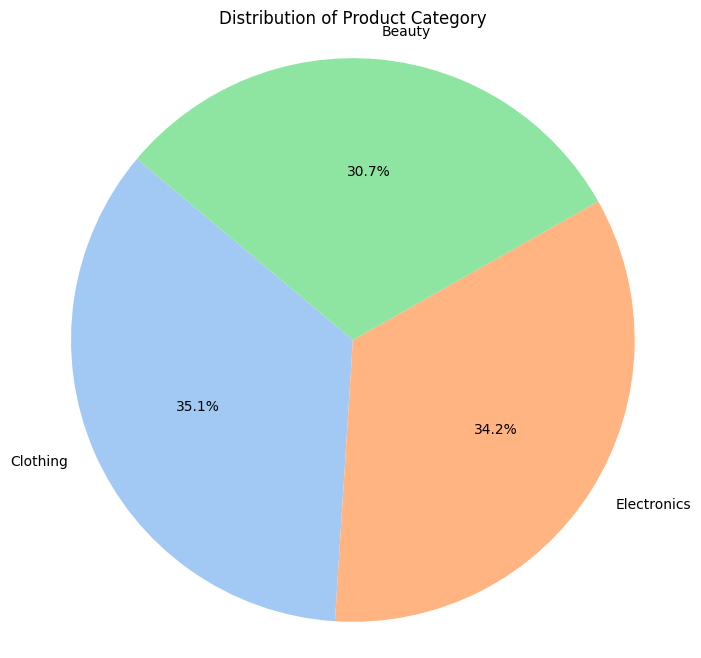

In [ ]:
category_counts = df['Product Category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Product Category')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_716/436945897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')


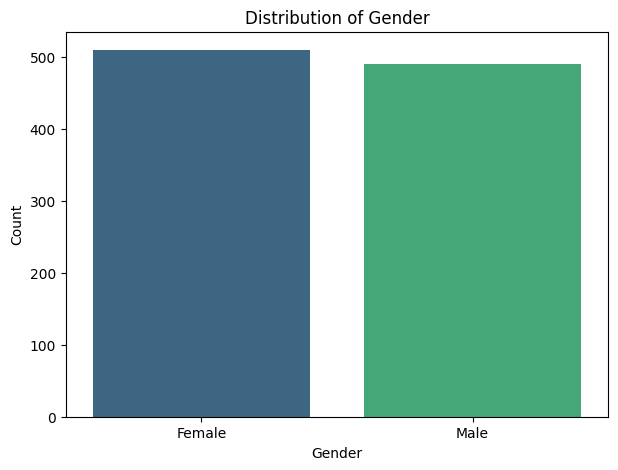

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

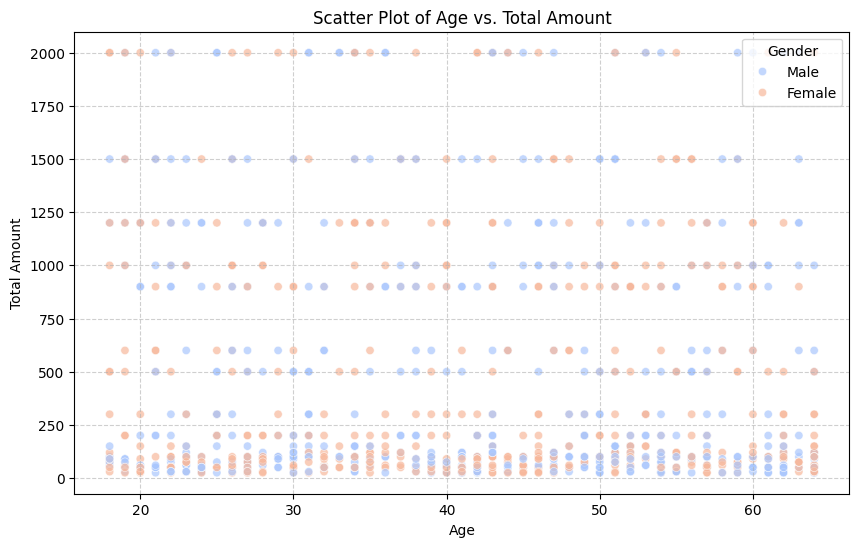

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Total Amount', data=df, hue='Gender', palette='coolwarm', alpha=0.7)
plt.title('Scatter Plot of Age vs. Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Total Sales by Product Category

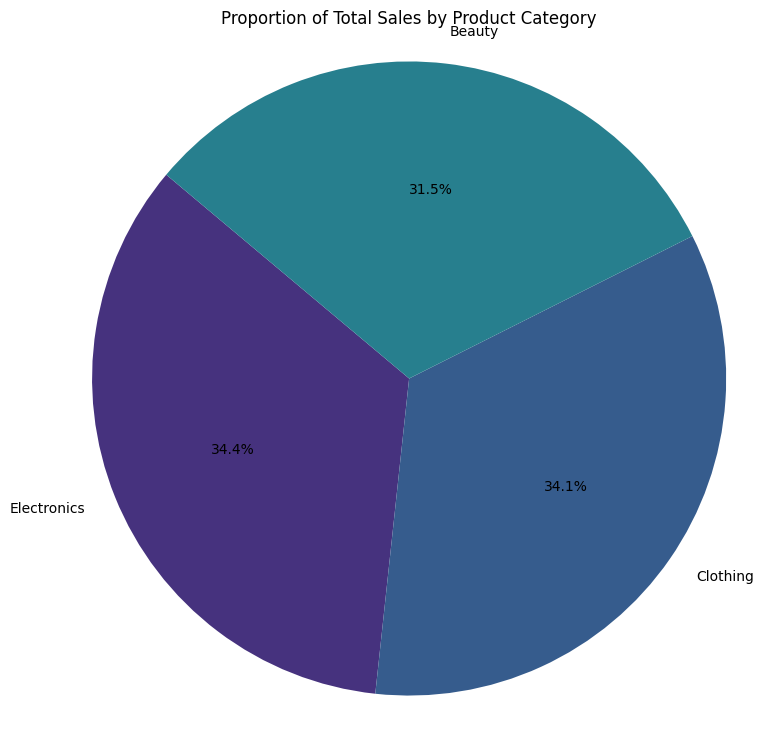

In [ ]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Proportion of Total Sales by Product Category')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This pie chart shows the percentage distribution of total sales across different product categories.

/tmp/ipykernel_716/324487090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='magma')


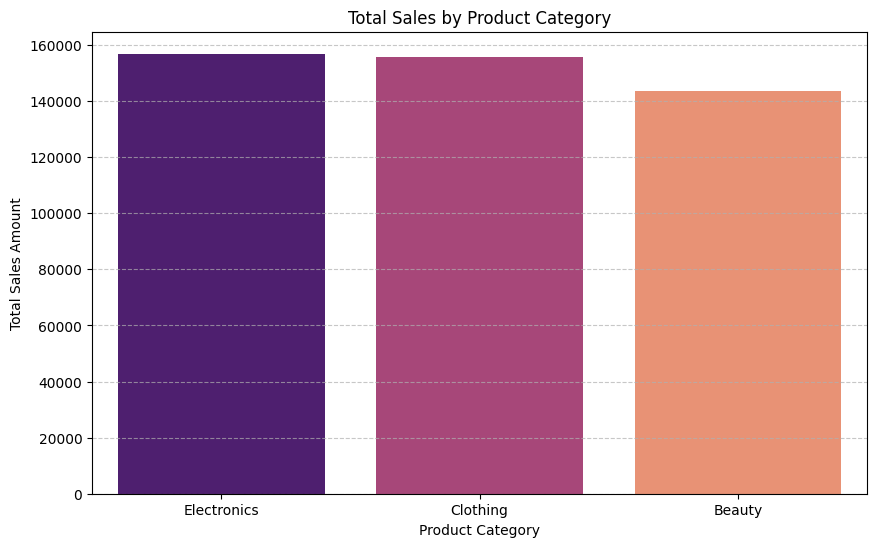

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='magma')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Numerical Analysis of Total Amount

# **NUMERICAL**

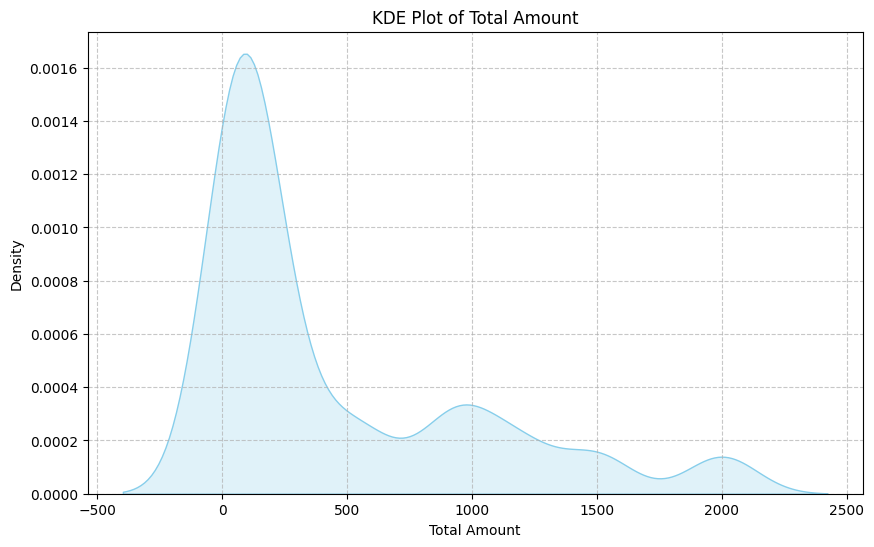

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Total Amount'], fill=True, color='skyblue')
plt.title('KDE Plot of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The Kernel Density Estimate (KDE) plot shows the probability density function of the 'Total Amount', providing a smooth representation of its distribution.

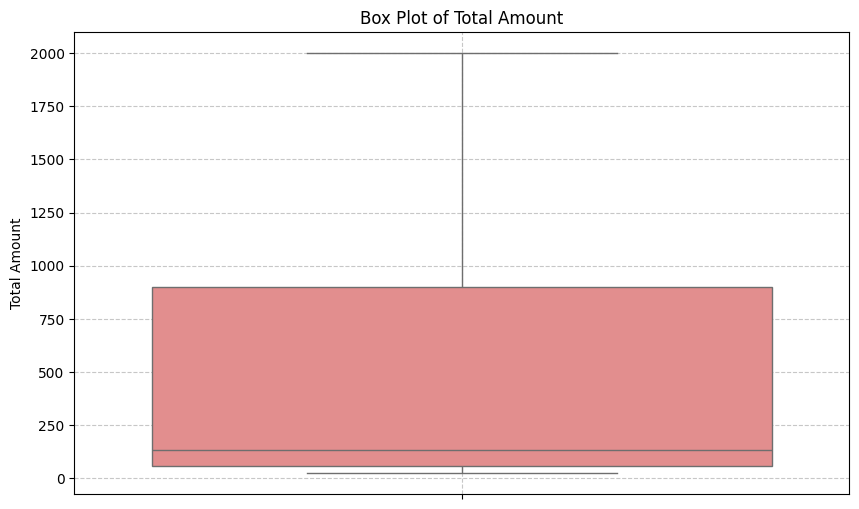

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Total Amount'], color='lightcoral')
plt.title('Box Plot of Total Amount')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The box plot provides a visual summary of the distribution of 'Total Amount', showing the median, quartiles, and potential outliers.

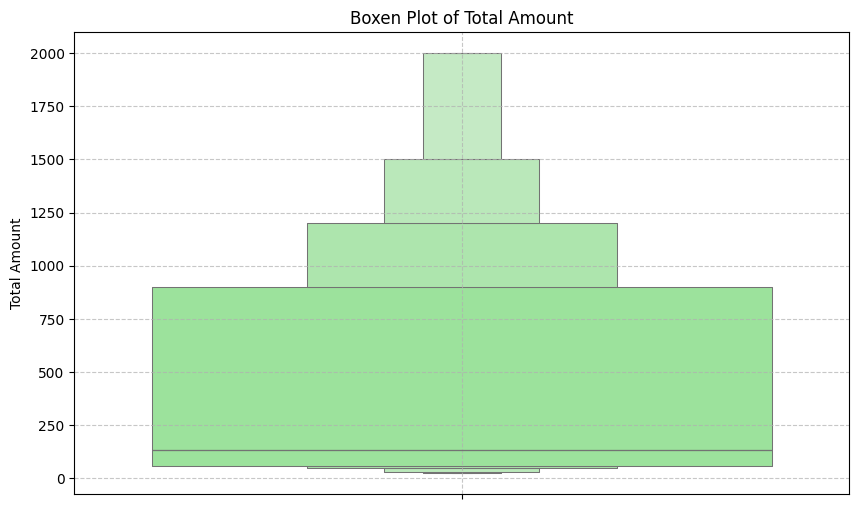

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxenplot(y=df['Total Amount'], color='lightgreen')
plt.title('Boxen Plot of Total Amount')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The boxen plot (or letter-value plot) is similar to a box plot but provides more information about the tails of the distribution, especially for larger datasets.

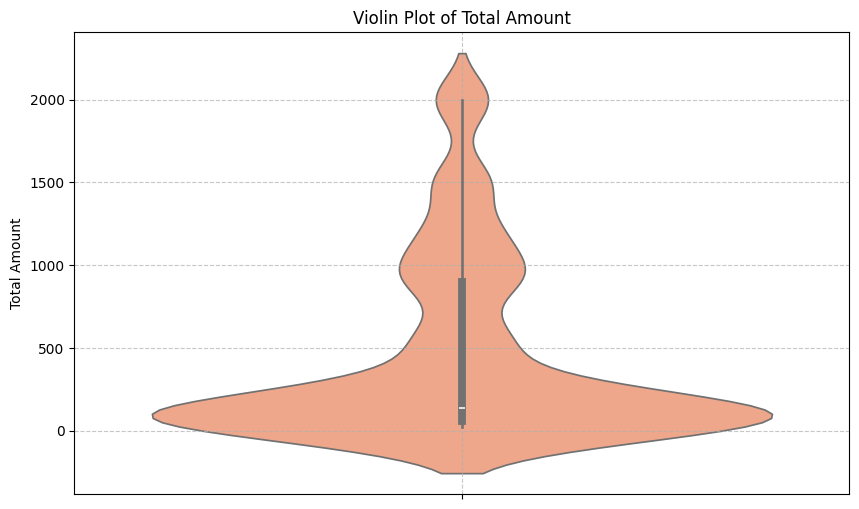

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['Total Amount'], color='lightsalmon')
plt.title('Violin Plot of Total Amount')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The violin plot combines aspects of a box plot and a KDE plot, showing both the distribution shape and summary statistics of 'Total Amount'.

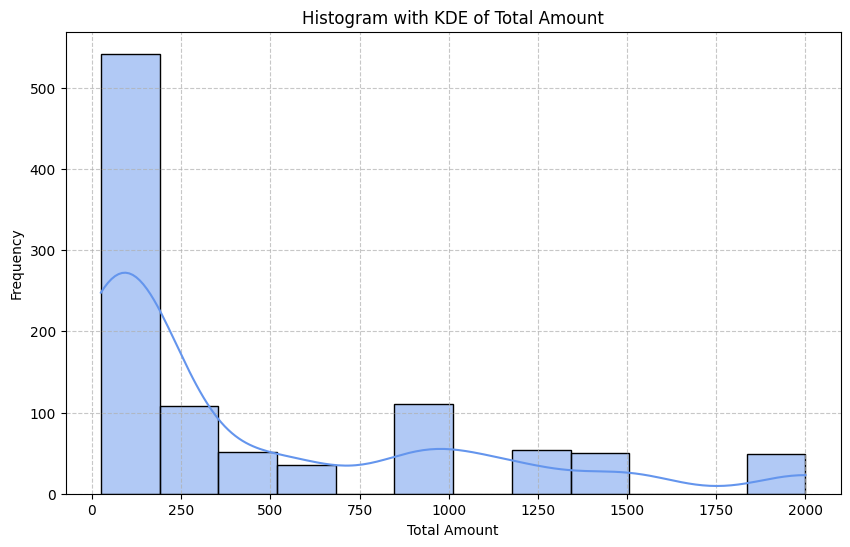

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Amount'], kde=True, color='cornflowerblue')
plt.title('Histogram with KDE of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This histogram, overlaid with a KDE curve, displays the frequency distribution of 'Total Amount', giving insights into its central tendency, spread, and shape.

### Distribution Plot for Age

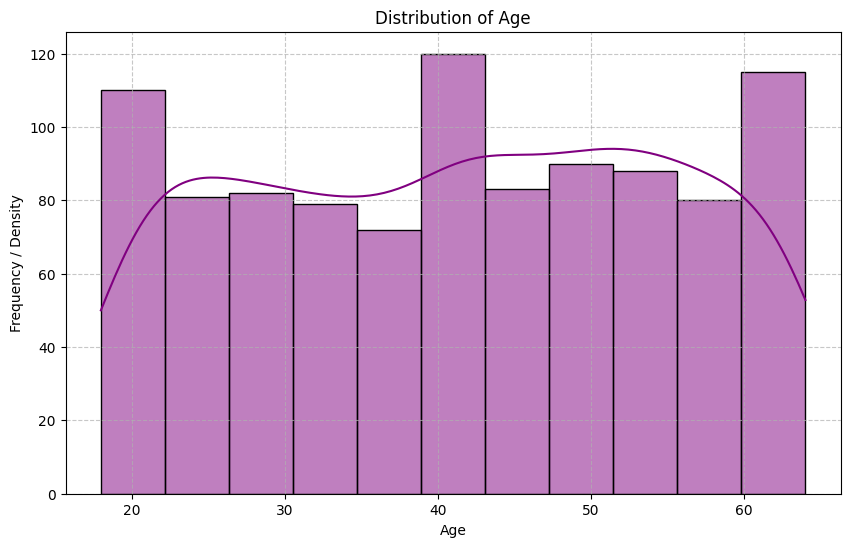

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='purple')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This plot displays the distribution of customer ages, showing their frequency and density. It helps in understanding the age demographics of the customer base.

# **BIVARIATE ANALYSIS**

**Numerical Numerical**

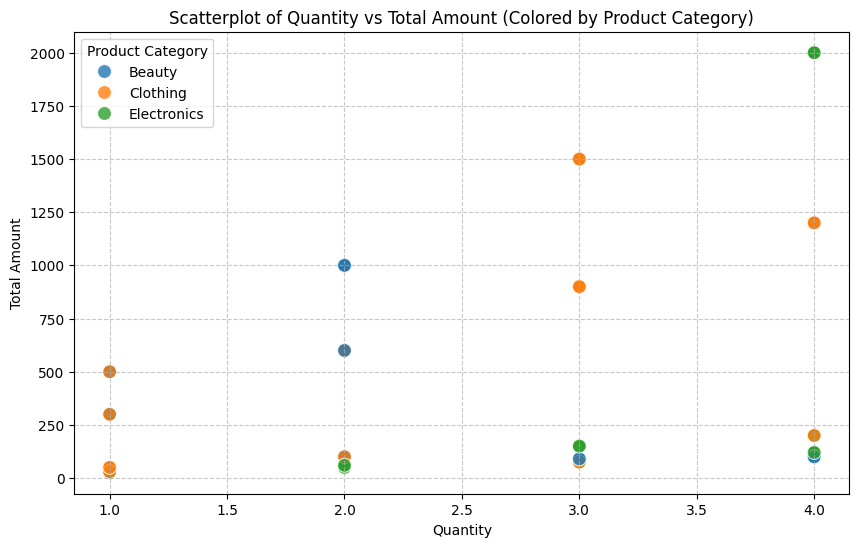

In [ ]:
# Scatterplot: Quantity vs Total Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Total Amount', data=df, hue='Product Category', palette='tab10', s=100, alpha=0.8)
plt.title('Scatterplot of Quantity vs Total Amount (Colored by Product Category)')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatterplot visualizes the relationship between the number of items purchased (`Quantity`) and the total amount spent (`Total Amount`), with points colored by `Product Category` to show how different categories influence this relationship.

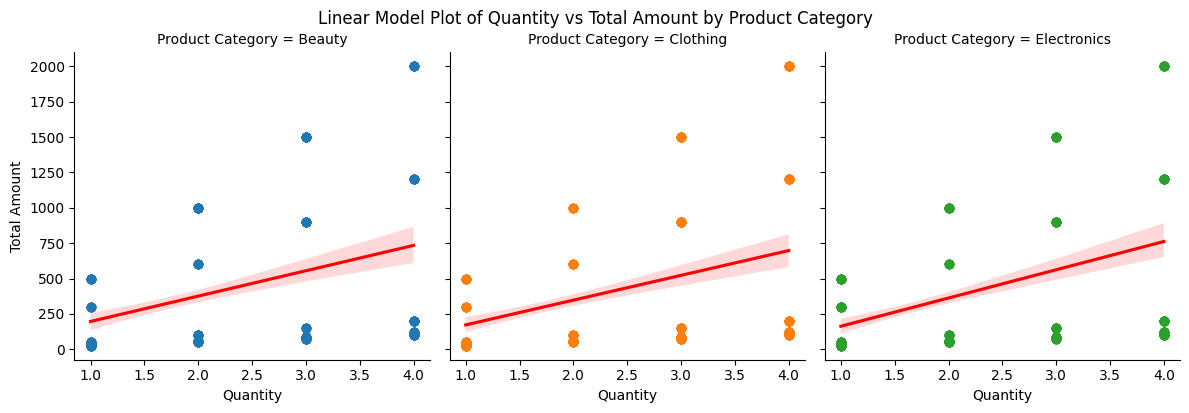

In [ ]:
# lmplot: Quantity vs Total Amount (with linear model fit)
sns.lmplot(x='Quantity', y='Total Amount', data=df, hue='Product Category', col='Product Category', col_wrap=3, height=4, scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.suptitle('Linear Model Plot of Quantity vs Total Amount by Product Category', y=1.02) # Adjust suptitle position
plt.show()

The `lmplot` extends the scatterplot by adding a linear regression line and its confidence interval for each product category, providing insight into the linear relationship between quantity and total amount.

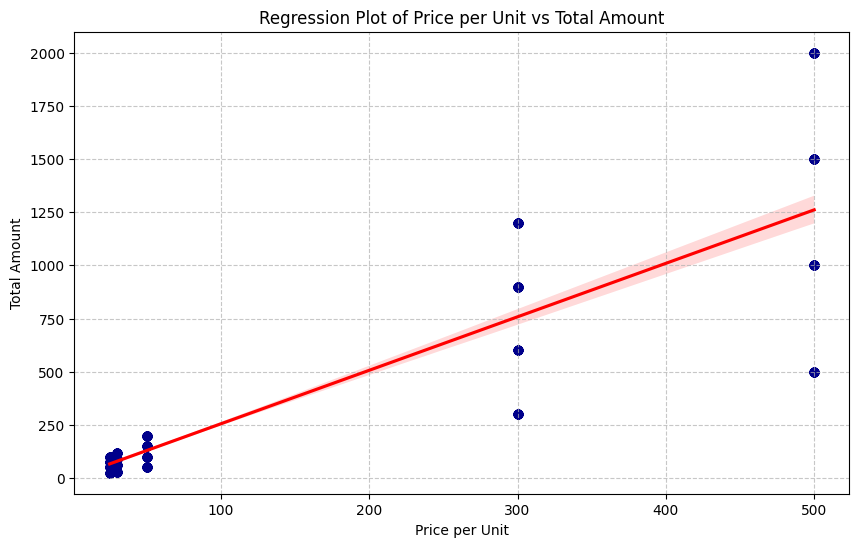

In [ ]:
# Regplot: Price per Unit vs Total Amount
plt.figure(figsize=(10, 6))
sns.regplot(x='Price per Unit', y='Total Amount', data=df, scatter_kws={'alpha':0.6, 'color':'darkblue'}, line_kws={'color': 'red'})
plt.title('Regression Plot of Price per Unit vs Total Amount')
plt.xlabel('Price per Unit')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This `regplot` shows the relationship between `Price per Unit` and `Total Amount`, along with a regression line to indicate the linear trend and a shaded confidence interval around it.

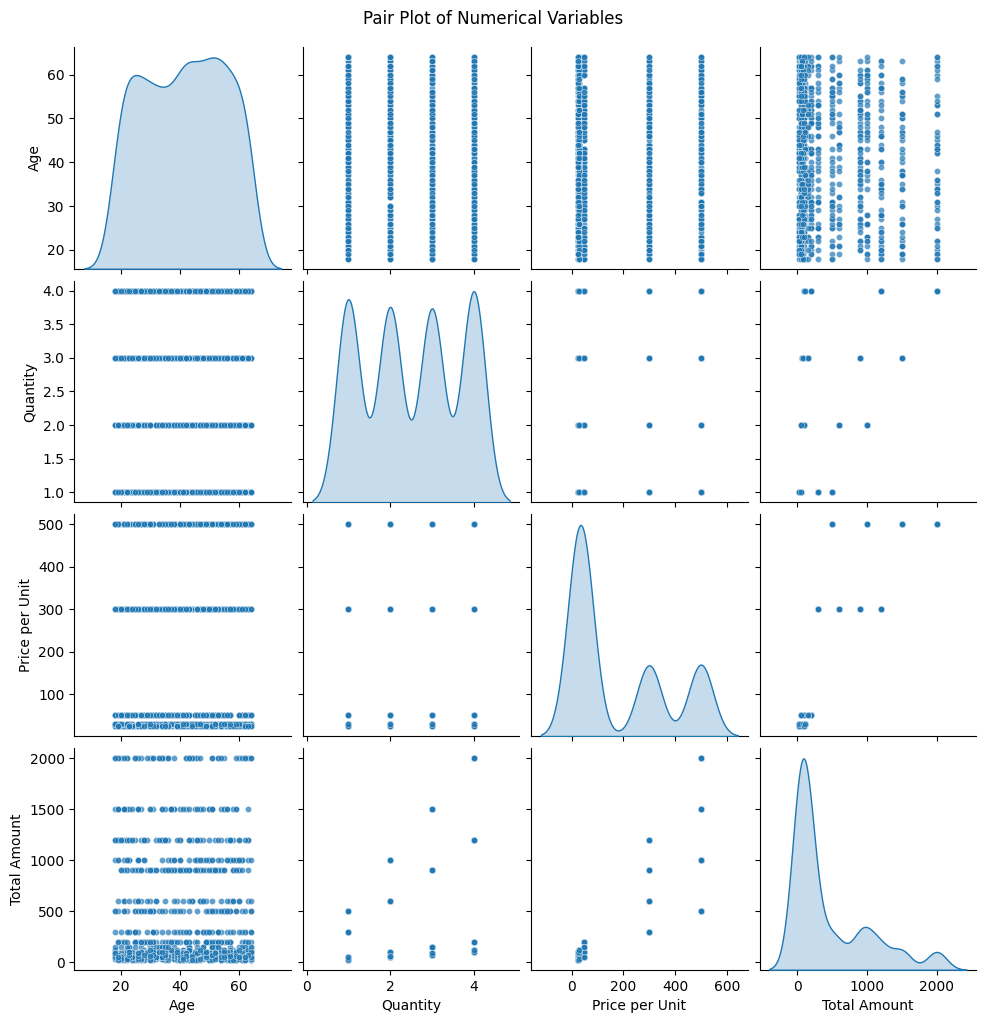

In [ ]:
# Pairplot for selected numerical columns
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
sns.pairplot(df[numerical_cols], diag_kind='kde', plot_kws={'alpha':0.7, 's':20})
plt.suptitle('Pair Plot of Numerical Variables', y=1.02) # Adjust suptitle position
plt.show()

A `pairplot` generates scatter plots for every pair of numerical variables and kernel density estimates (KDEs) for the univariate distributions, offering a quick overview of all pairwise relationships and individual distributions.

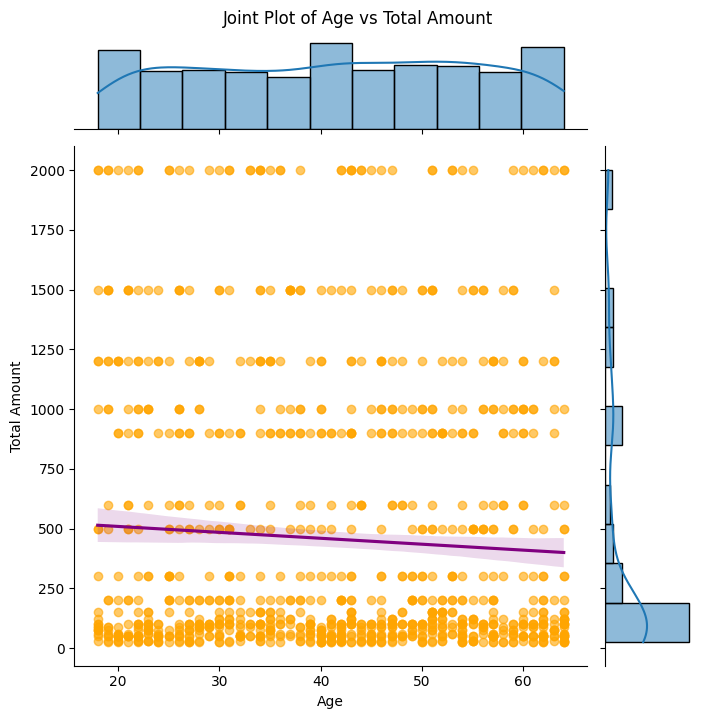

In [ ]:
# Jointplot: Age vs Total Amount
sns.jointplot(x='Age', y='Total Amount', data=df, kind='reg', height=7, scatter_kws={'alpha':0.6, 'color':'orange'}, line_kws={'color': 'purple'})
plt.suptitle('Joint Plot of Age vs Total Amount', y=1.02) # Adjust suptitle position
plt.show()

### Total Sales by Product Category and Gender

This bar chart illustrates the total sales amount for each product category, with bars grouped by gender. It allows for a direct comparison of sales performance across categories between male and female customers.

The `jointplot` combines a scatter plot of `Age` and `Total Amount` with their respective marginal distributions (histograms in this case), and also includes a regression line and KDE contours for the joint distribution.

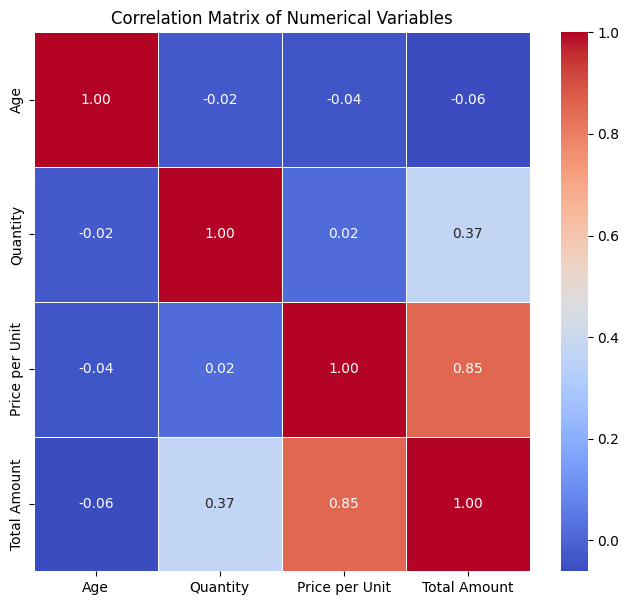

In [ ]:
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

This heatmap displays the pairwise correlation coefficients between numerical variables. The color intensity and annotations indicate the strength and direction of the linear relationship between each pair of variables.

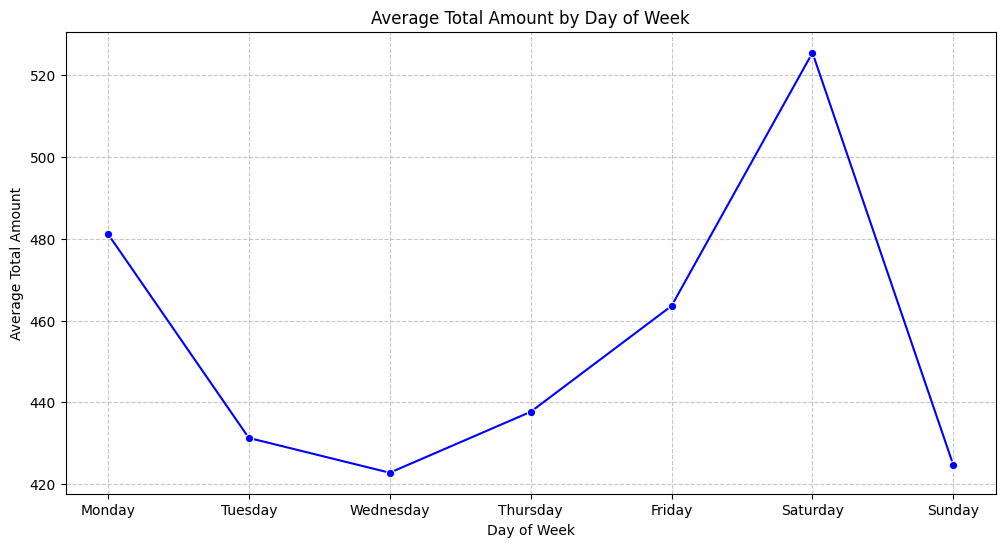

In [ ]:
average_sales_by_day = df.groupby('Day of Week')['Total Amount'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 6))
sns.lineplot(x=average_sales_by_day.index, y=average_sales_by_day.values, marker='o', color='blue')
plt.title('Average Total Amount by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This line plot displays the average 'Total Amount' for each 'Day of Week', allowing us to identify patterns and trends in customer spending behavior throughout the week.

**NUMERICAL CATEGORICAL**

/tmp/ipykernel_716/924545644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount', data=df, palette='Spectral')


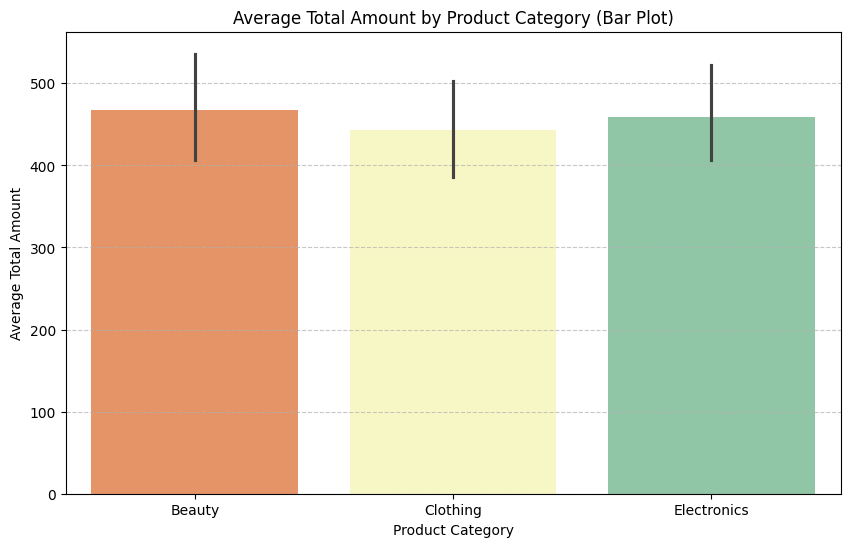

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Product Category', y='Total Amount', data=df, palette='Spectral')
plt.title('Average Total Amount by Product Category (Bar Plot)')
plt.xlabel('Product Category')
plt.ylabel('Average Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar plot shows the average 'Total Amount' for each 'Product Category'. It helps to quickly compare the average spending across different product types.

/tmp/ipykernel_716/3738722895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Category', y='Total Amount', data=df, palette='pastel')


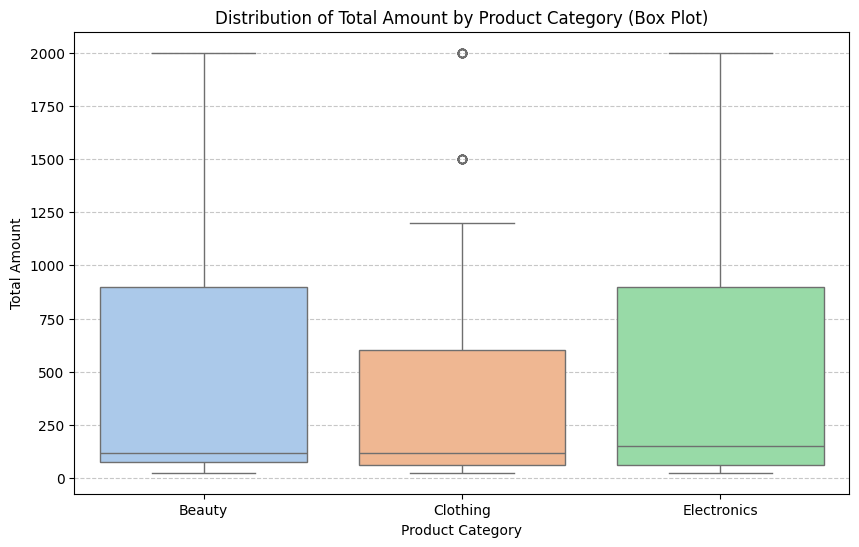

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Product Category', y='Total Amount', data=df, palette='pastel')
plt.title('Distribution of Total Amount by Product Category (Box Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This box plot illustrates the distribution of 'Total Amount' for each 'Product Category', showing the median, quartiles, and potential outliers. It's useful for understanding the spread and central tendency of sales within each category.

/tmp/ipykernel_716/781942199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Product Category', y='Total Amount', data=df, palette='viridis')


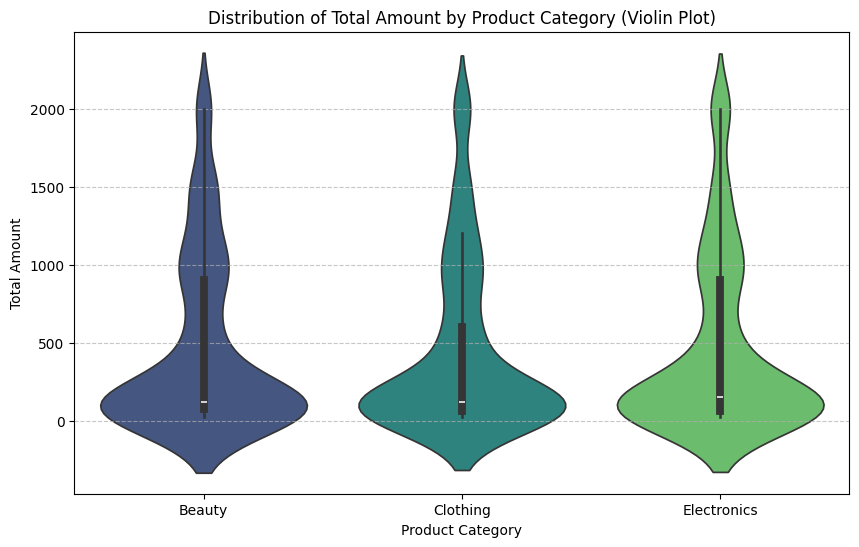

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Product Category', y='Total Amount', data=df, palette='viridis')
plt.title('Distribution of Total Amount by Product Category (Violin Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The violin plot combines aspects of a box plot and a kernel density estimate, showing the distribution shape of 'Total Amount' for each 'Product Category'. This gives a richer understanding of the data's density at different values.

/tmp/ipykernel_716/809329383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Product Category', y='Total Amount', data=df, jitter=True, palette='plasma', alpha=0.7)


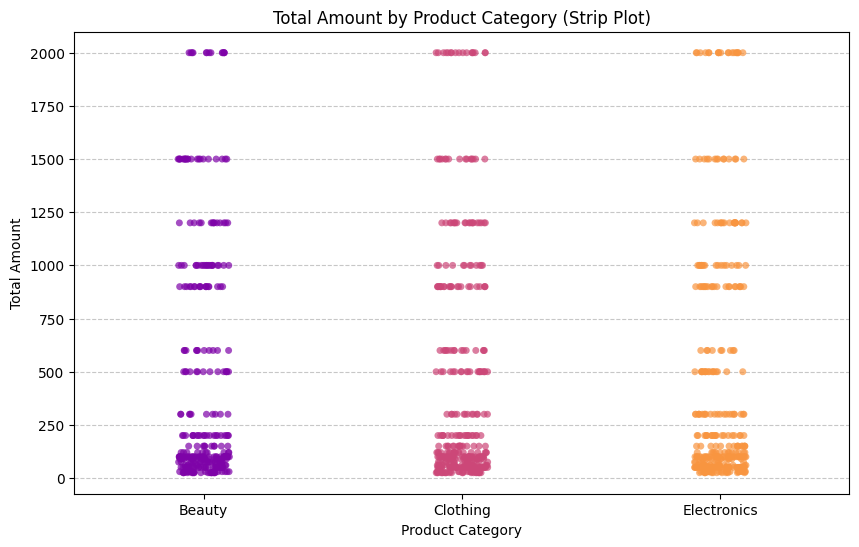

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='Product Category', y='Total Amount', data=df, jitter=True, palette='plasma', alpha=0.7)
plt.title('Total Amount by Product Category (Strip Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This strip plot shows all individual data points of 'Total Amount' for each 'Product Category'. Jitter is added to prevent overlapping points, offering a clear view of the density and spread of observations.

/tmp/ipykernel_716/3360215499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Product Category', y='Total Amount', data=df, palette='magma')
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packa

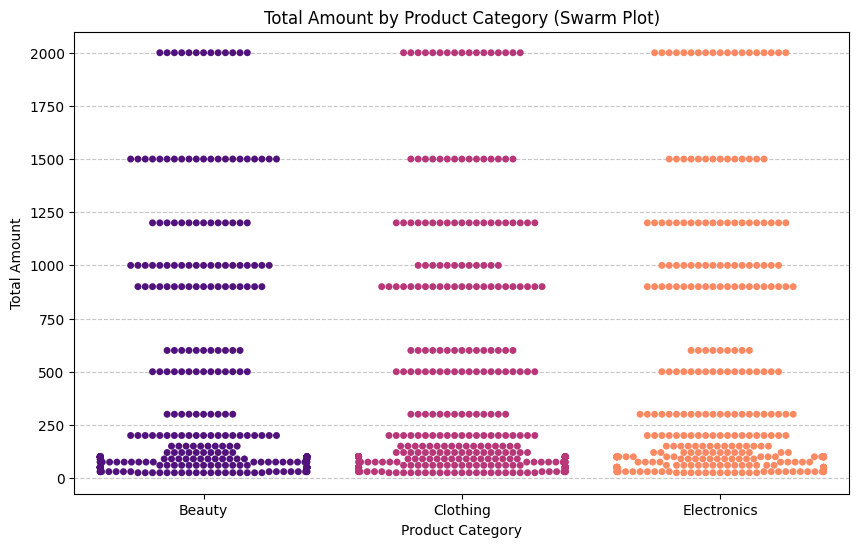

In [ ]:
plt.figure(figsize=(10, 6))
sns.swarmplot(x='Product Category', y='Total Amount', data=df, palette='magma')
plt.title('Total Amount by Product Category (Swarm Plot)')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The swarm plot is similar to a strip plot but arranges points so they don't overlap, providing a better representation of the distribution's density. It's especially useful for smaller datasets where individual points are important.

# CATEGORICAI CATEGORICAI

**SIDE BY SIDE GRAPH**

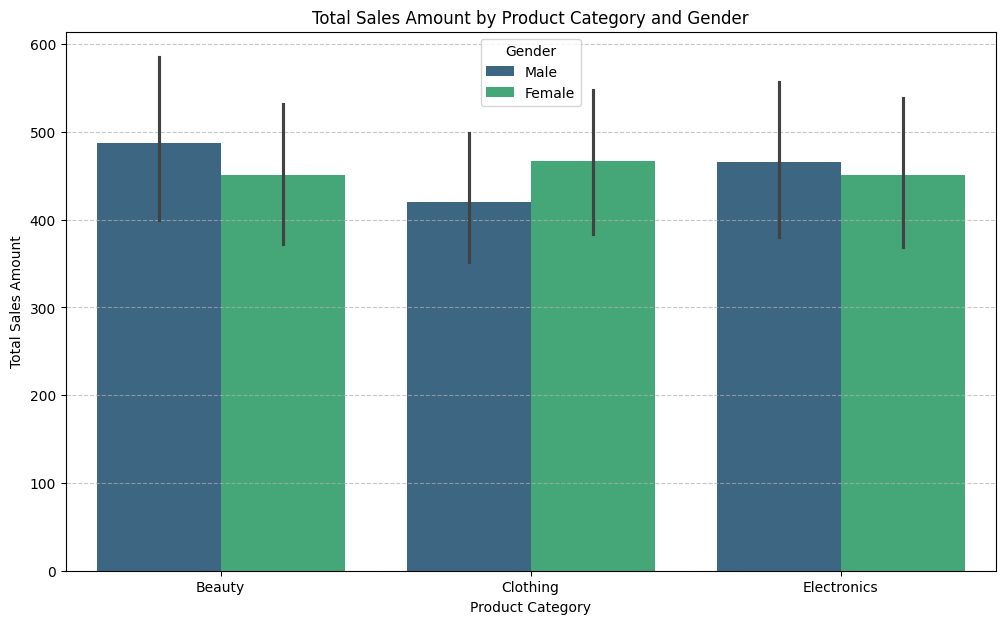

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Category', y='Total Amount', hue='Gender', data=df, palette='viridis')
plt.title('Total Sales Amount by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.show()

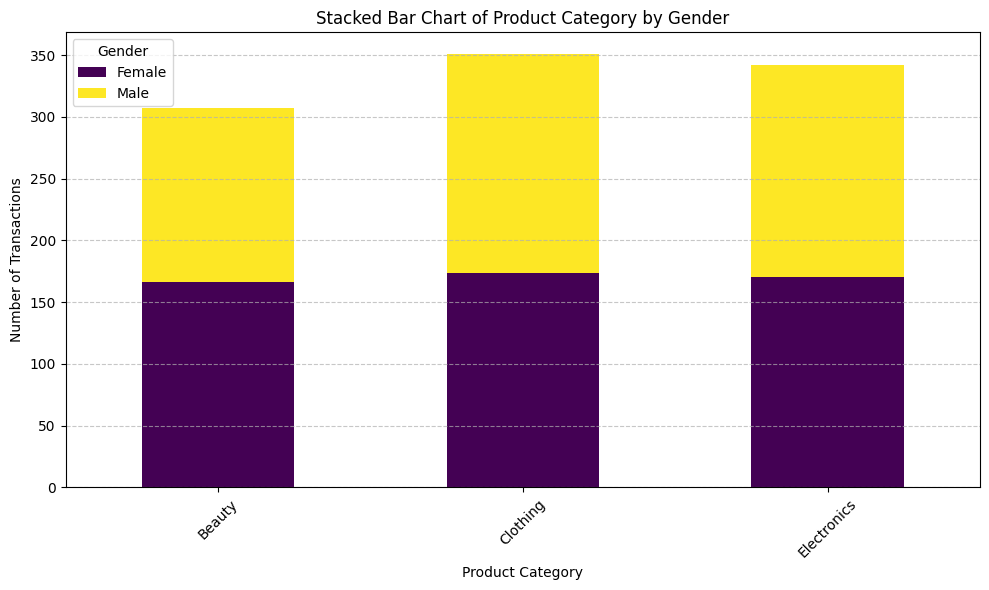

In [ ]:
# Create a cross-tabulation of Product Category and Gender
crosstab_df = pd.crosstab(df['Product Category'], df['Gender'])

# Plotting the stacked bar chart
crosstab_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Stacked Bar Chart of Product Category by Gender')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This stacked bar chart shows the total number of transactions for each product category, with the bars segmented by gender. It allows for a clear comparison of the proportion of male and female customers within each product category.

### Feature Engineering: Adding 'Profit Margin'

In [ ]:
df['Profit Margin'] = df['Total Amount'] / df['Quantity']
display(df.head())

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Profit Margin
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,50.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,500.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,50.0


The 'Profit Margin' feature has been calculated as 'Total Amount' divided by 'Quantity' for each transaction. This new feature can provide insights into the profitability of individual sales.

### Feature Engineering: Adding Time-Based Features

In [ ]:
df['Day of Week'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['Is Weekend'] = df['Date'].dt.dayofweek >= 5 # Saturday (5) or Sunday (6)
display(df.head())

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Profit Margin,Day of Week,Month,Year,Is Weekend
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,50.0,Friday,November,2023,False
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,500.0,Monday,February,2023,False
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30.0,Friday,January,2023,False
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500.0,Sunday,May,2023,True
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,50.0,Saturday,May,2023,True


I've added 'Day of Week', 'Month', 'Year', and 'Is Weekend' columns to the DataFrame. These new features will allow us to analyze how sales and other metrics vary across different periods.